In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



In [5]:
df = pd.read_csv(r"C:\Users\Divija Vallapuneni\Downloads\sales_forecasting_dataset.csv")
df.head()

,Date,Sales,Profit,Quantity,Discount
0,2025-01-01,12000,1800,120,10
1,2025-02-01,12500,1900,125,8
2,2025-03-01,13000,2000,130,12
3,2025-04-01,12800,1950,128,15
4,2025-05-01,13500,2100,135,10


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Date      12 non-null     object
 1   Sales     12 non-null     int64 
 2   Profit    12 non-null     int64 
 3   Quantity  12 non-null     int64 
 4   Discount  12 non-null     int64 
dtypes: int64(4), object(1)
memory usage: 612.0+ bytes


In [7]:
df.isnull().sum()

Date        0
Sales       0
Profit      0
Quantity    0
Discount    0
dtype: int64

In [11]:
df['Date'] = pd.to_datetime(df['Date'])
print(df)

         Date  Sales  Profit  Quantity  Discount
0  2025-01-01  12000    1800       120        10
1  2025-02-01  12500    1900       125         8
2  2025-03-01  13000    2000       130        12
3  2025-04-01  12800    1950       128        15
4  2025-05-01  13500    2100       135        10
5  2025-06-01  14000    2200       140         5
6  2025-07-01  14500    2300       145         8
7  2025-08-01  15000    2400       150        10
8  2025-09-01  14800    2350       148        12
9  2025-10-01  15500    2500       155         8
10 2025-11-01  16000    2600       160         5
11 2025-12-01  16500    2700       165        10


In [12]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
print(df)

         Date  Sales  Profit  Quantity  Discount  Year  Month
0  2025-01-01  12000    1800       120        10  2025      1
1  2025-02-01  12500    1900       125         8  2025      2
2  2025-03-01  13000    2000       130        12  2025      3
3  2025-04-01  12800    1950       128        15  2025      4
4  2025-05-01  13500    2100       135        10  2025      5
5  2025-06-01  14000    2200       140         5  2025      6
6  2025-07-01  14500    2300       145         8  2025      7
7  2025-08-01  15000    2400       150        10  2025      8
8  2025-09-01  14800    2350       148        12  2025      9
9  2025-10-01  15500    2500       155         8  2025     10
10 2025-11-01  16000    2600       160         5  2025     11
11 2025-12-01  16500    2700       165        10  2025     12


In [13]:
df.head()

,Date,Sales,Profit,Quantity,Discount,Year,Month
0,2025-01-01,12000,1800,120,10,2025,1
1,2025-02-01,12500,1900,125,8,2025,2
2,2025-03-01,13000,2000,130,12,2025,3
3,2025-04-01,12800,1950,128,15,2025,4
4,2025-05-01,13500,2100,135,10,2025,5


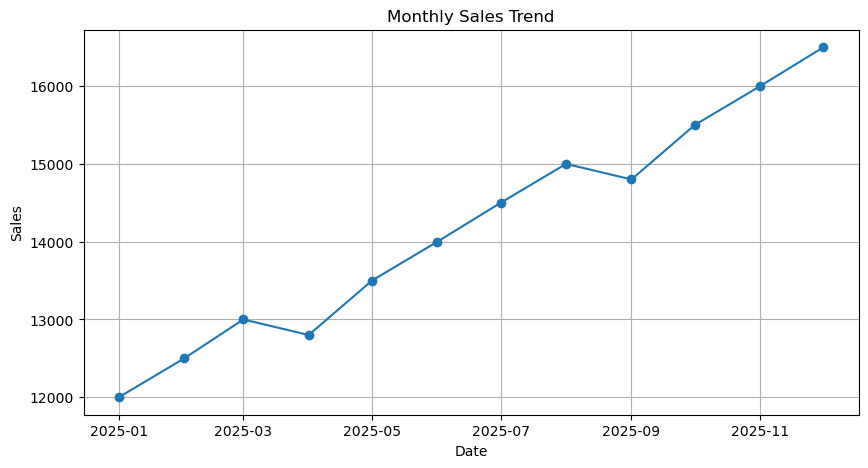

In [14]:
plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['Sales'], marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

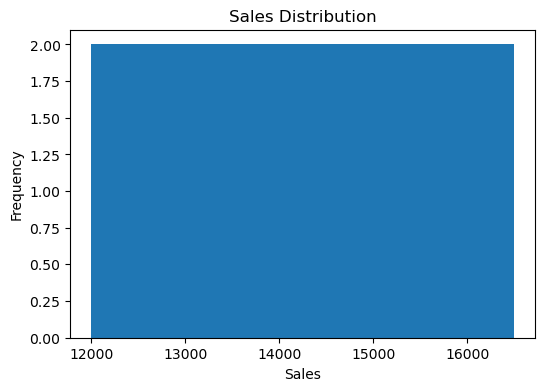

In [15]:
plt.figure(figsize=(6,4))
plt.hist(df['Sales'], bins=6)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

In [17]:


X = df[['Year', 'Month', 'Profit', 'Quantity', 'Discount']]
y = df['Sales']

print("Independent Variables (X):")
print(X.head())

print("\nDependent Variable (y):")
print(y.head())

Independent Variables (X):
   Year  Month  Profit  Quantity  Discount
0  2025      1    1800       120        10
1  2025      2    1900       125         8
2  2025      3    2000       130        12
3  2025      4    1950       128        15
4  2025      5    2100       135        10

Dependent Variable (y):
0    12000
1    12500
2    13000
3    12800
4    13500
Name: Sales, dtype: int64


In [18]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Features Shape:", X_train.shape)
print("Testing Features Shape :", X_test.shape)
print("Training Target Shape  :", y_train.shape)
print("Testing Target Shape   :", y_test.shape)

print("\nTraining Features (First 5 Rows):")
print(X_train.head())

print("\nTesting Features (First 5 Rows):")
print(X_test.head())

Training Features Shape: (9, 5)
Testing Features Shape : (3, 5)
Training Target Shape  : (9,)
Testing Target Shape   : (3,)

Training Features (First 5 Rows):
    Year  Month  Profit  Quantity  Discount
8   2025      9    2350       148        12
5   2025      6    2200       140         5
2   2025      3    2000       130        12
1   2025      2    1900       125         8
11  2025     12    2700       165        10

Testing Features (First 5 Rows):
    Year  Month  Profit  Quantity  Discount
10  2025     11    2600       160         5
9   2025     10    2500       155         8
0   2025      1    1800       120        10


In [19]:


model = LinearRegression()


model.fit(X_train, y_train)

print("Model trained successfully!")


print("\nModel Coefficients:")
print(model.coef_)

print("\nModel Intercept:")
print(model.intercept_)

Model trained successfully!

Model Coefficients:
[0.00000000e+00 1.29143709e-13 4.74498466e-14 1.00000000e+02
 2.00296843e-13]

Model Intercept:
4.3655745685100555e-11


In [20]:

y_pred = model.predict(X_test)

print("Sales Prediction Completed Successfully!")

print("\nPredicted Sales:")
print(y_pred)

print("\nActual Sales:")
print(y_test.values)

Sales Prediction Completed Successfully!

Predicted Sales:
[16000. 15500. 12000.]

Actual Sales:
[16000 15500 12000]


In [21]:


result = pd.DataFrame({
    'Actual Sales': y_test.values,
    'Predicted Sales': y_pred
})

print("Actual vs Predicted Sales")
print(result)


print("\nFirst 5 Predictions:")
print(result.head())

Actual vs Predicted Sales
   Actual Sales  Predicted Sales
0         16000          16000.0
1         15500          15500.0
2         12000          12000.0

First 5 Predictions:
   Actual Sales  Predicted Sales
0         16000          16000.0
1         15500          15500.0
2         12000          12000.0


In [22]:


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(" Model Evaluation ")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

 Model Evaluation 
Mean Absolute Error (MAE): 0.00
Mean Squared Error (MSE): 0.00
Root Mean Squared Error (RMSE): 0.00
R² Score: 1.00


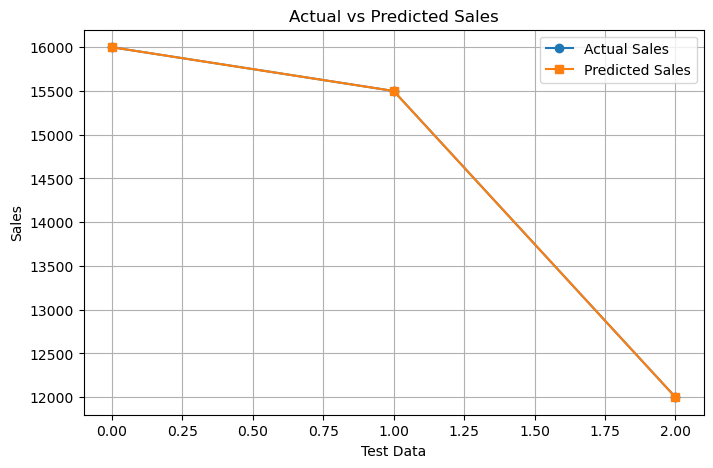

Actual vs Predicted Sales graph generated successfully!


In [23]:


plt.figure(figsize=(8,5))

plt.plot(y_test.values, marker='o', label='Actual Sales')
plt.plot(y_pred, marker='s', label='Predicted Sales')

plt.title("Actual vs Predicted Sales")
plt.xlabel("Test Data")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()

print("Actual vs Predicted Sales graph generated successfully!")

In [24]:


future = pd.DataFrame({
    'Year': [2026, 2026, 2026, 2026, 2026, 2026],
    'Month': [1, 2, 3, 4, 5, 6],
    'Profit': [2800, 2900, 3000, 3100, 3200, 3300],
    'Quantity': [170, 175, 180, 185, 190, 195],
    'Discount': [8, 10, 7, 9, 8, 10]
})

future['Predicted Sales'] = model.predict(future)

print("Future Sales Forecast")
print(future)

Future Sales Forecast
   Year  Month  Profit  Quantity  Discount  Predicted Sales
0  2026      1    2800       170         8          17000.0
1  2026      2    2900       175        10          17500.0
2  2026      3    3000       180         7          18000.0
3  2026      4    3100       185         9          18500.0
4  2026      5    3200       190         8          19000.0
5  2026      6    3300       195        10          19500.0


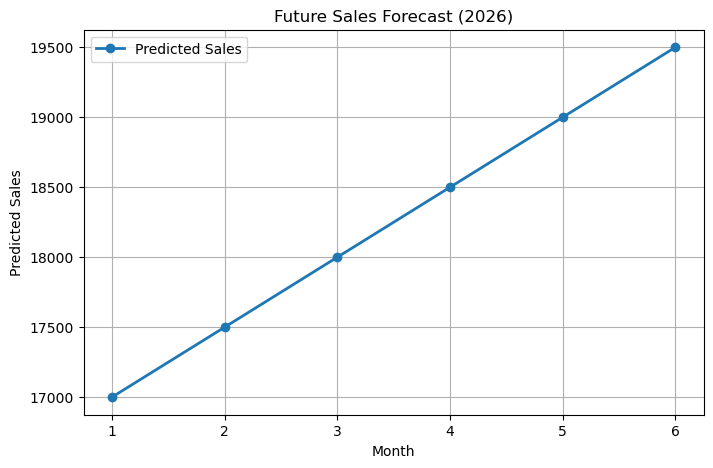

Future Sales Forecast Graph generated successfully!


In [25]:


plt.figure(figsize=(8,5))

plt.plot(
    future['Month'],
    future['Predicted Sales'],
    marker='o',
    linewidth=2,
    label='Predicted Sales'
)

plt.title("Future Sales Forecast (2026)")
plt.xlabel("Month")
plt.ylabel("Predicted Sales")
plt.xticks(future['Month'])
plt.grid(True)
plt.legend()

plt.show()

print("Future Sales Forecast Graph generated successfully!")

In [26]:
# Step 13: Conclusion

print("========== Project Summary ==========")
print("1. Historical sales data was loaded successfully.")
print("2. Data preprocessing and feature engineering were completed.")
print("3. A Linear Regression model was trained using historical data.")
print("4. The model predicted future sales successfully.")
print("5. Model performance was evaluated using MAE, MSE, RMSE, and R² Score.")
print("6. Visualizations were created for actual vs predicted sales and future forecasts.")
print("7. This project demonstrates predictive analytics using historical data.")

========== Project Summary ==========
1. Historical sales data was loaded successfully.
2. Data preprocessing and feature engineering were completed.
3. A Linear Regression model was trained using historical data.
4. The model predicted future sales successfully.
5. Model performance was evaluated using MAE, MSE, RMSE, and R² Score.
6. Visualizations were created for actual vs predicted sales and future forecasts.
7. This project demonstrates predictive analytics using historical data.
